In [5]:
#Jupyter Notebook config
%load_ext autoreload
%autoreload 2
%matplotlib widget

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [12]:
#Load necessary python packages
import matplotlib.pyplot as plt
from matplotlib import colormaps
import cartopy.crs as ccrs
import cartopy.feature as cfeature

from cmocean import cm
import numpy as np
import xarray as xr
import seaborn as sns

from ipywidgets import widgets
from IPython.display import display

#Import custom package for working with Beaufort Gyre data
from datatools import io
import datatools.ctd.operations as dsops
import datatools.plots.maps as mapper
import datatools.plots.section as plotter
import ocean_tools as fod
from datatools.DOT.DataServer import DataServer

In [15]:
#Load in CTD Datafile
if True:
    #Or load from a pre-processed datafile
    path = "/Users/ben/Desktop/3D-TEA-BAG/data/processed"
    e_ns_transect = xr.load_dataset(f"{path}/e_ns_transect.nc")
    w_ns_transect = xr.load_dataset(f"{path}/w_ns_transect.nc")
    n_ew_transect = xr.load_dataset(f"{path}/n_ew_transect.nc")
    s_ew_transect = xr.load_dataset(f"{path}/s_ew_transect.nc")

e_ns_cruise_transects = dsops.to_dict_by_cruise(e_ns_transect)
w_ns_cruise_transects = dsops.to_dict_by_cruise(w_ns_transect)
n_ew_cruise_transects = dsops.to_dict_by_cruise(n_ew_transect)
s_ew_cruise_transects = dsops.to_dict_by_cruise(s_ew_transect)

In [ ]:
#Load in Satellite Data
sat_data = DataServer("/Users/ben/Desktop/3D-TEA-BAG/data/CPOM_DOT.nc", "/Users/ben/Desktop/3D-TEA-BAG/data/Full_DOT_data_Arco_2025_09.nc")

In [ ]:
def plot_currents(year: int, ax: plt.Axes) -> plt.Axes:
    if year < 2015:
        sub_ds = sat_data.sat_ds_old.sel(lat = slice(extent[2],extent[3],step), lon = slice(extent[0],extent[1],step), time = np.datetime64(f"{year}-09-01"))

        lon_mesh, lat_mesh = np.meshgrid(sub_ds['lon'], sub_ds['lat'])



        #Plot the surface currents
        ax.quiver(lon_mesh, lat_mesh, sub_ds['U'].values, sub_ds['V'].values, transform = ccrs.PlateCarree(), label = 'Geostrophic Surface Current')

        #Finish the plot off
        ax.set_title(f"September {year}")

KeyError: "not all values found in index 'time'. Try setting the `method` keyword argument (example: method='nearest')."

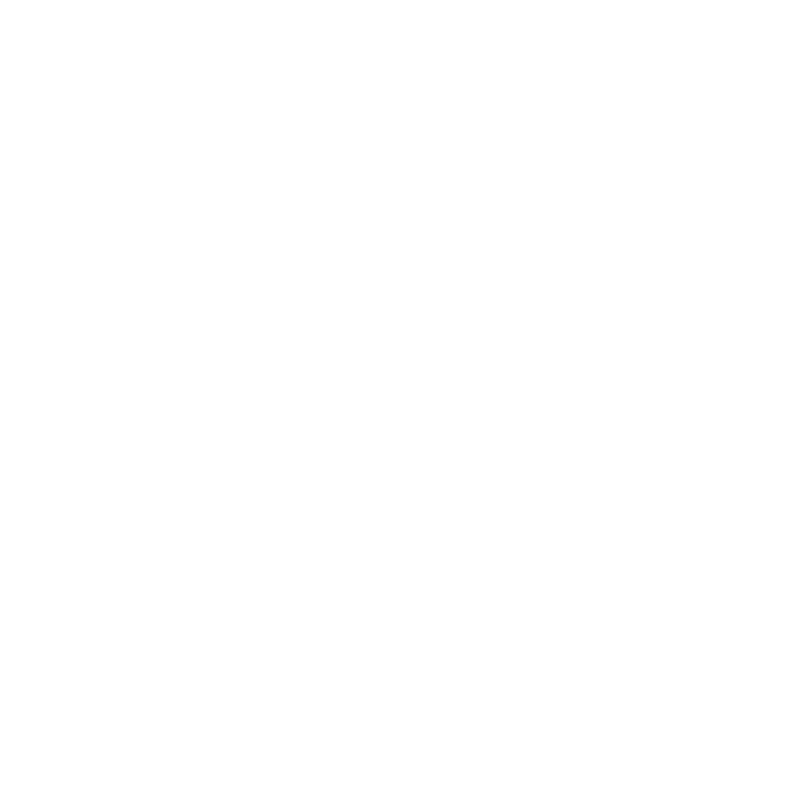

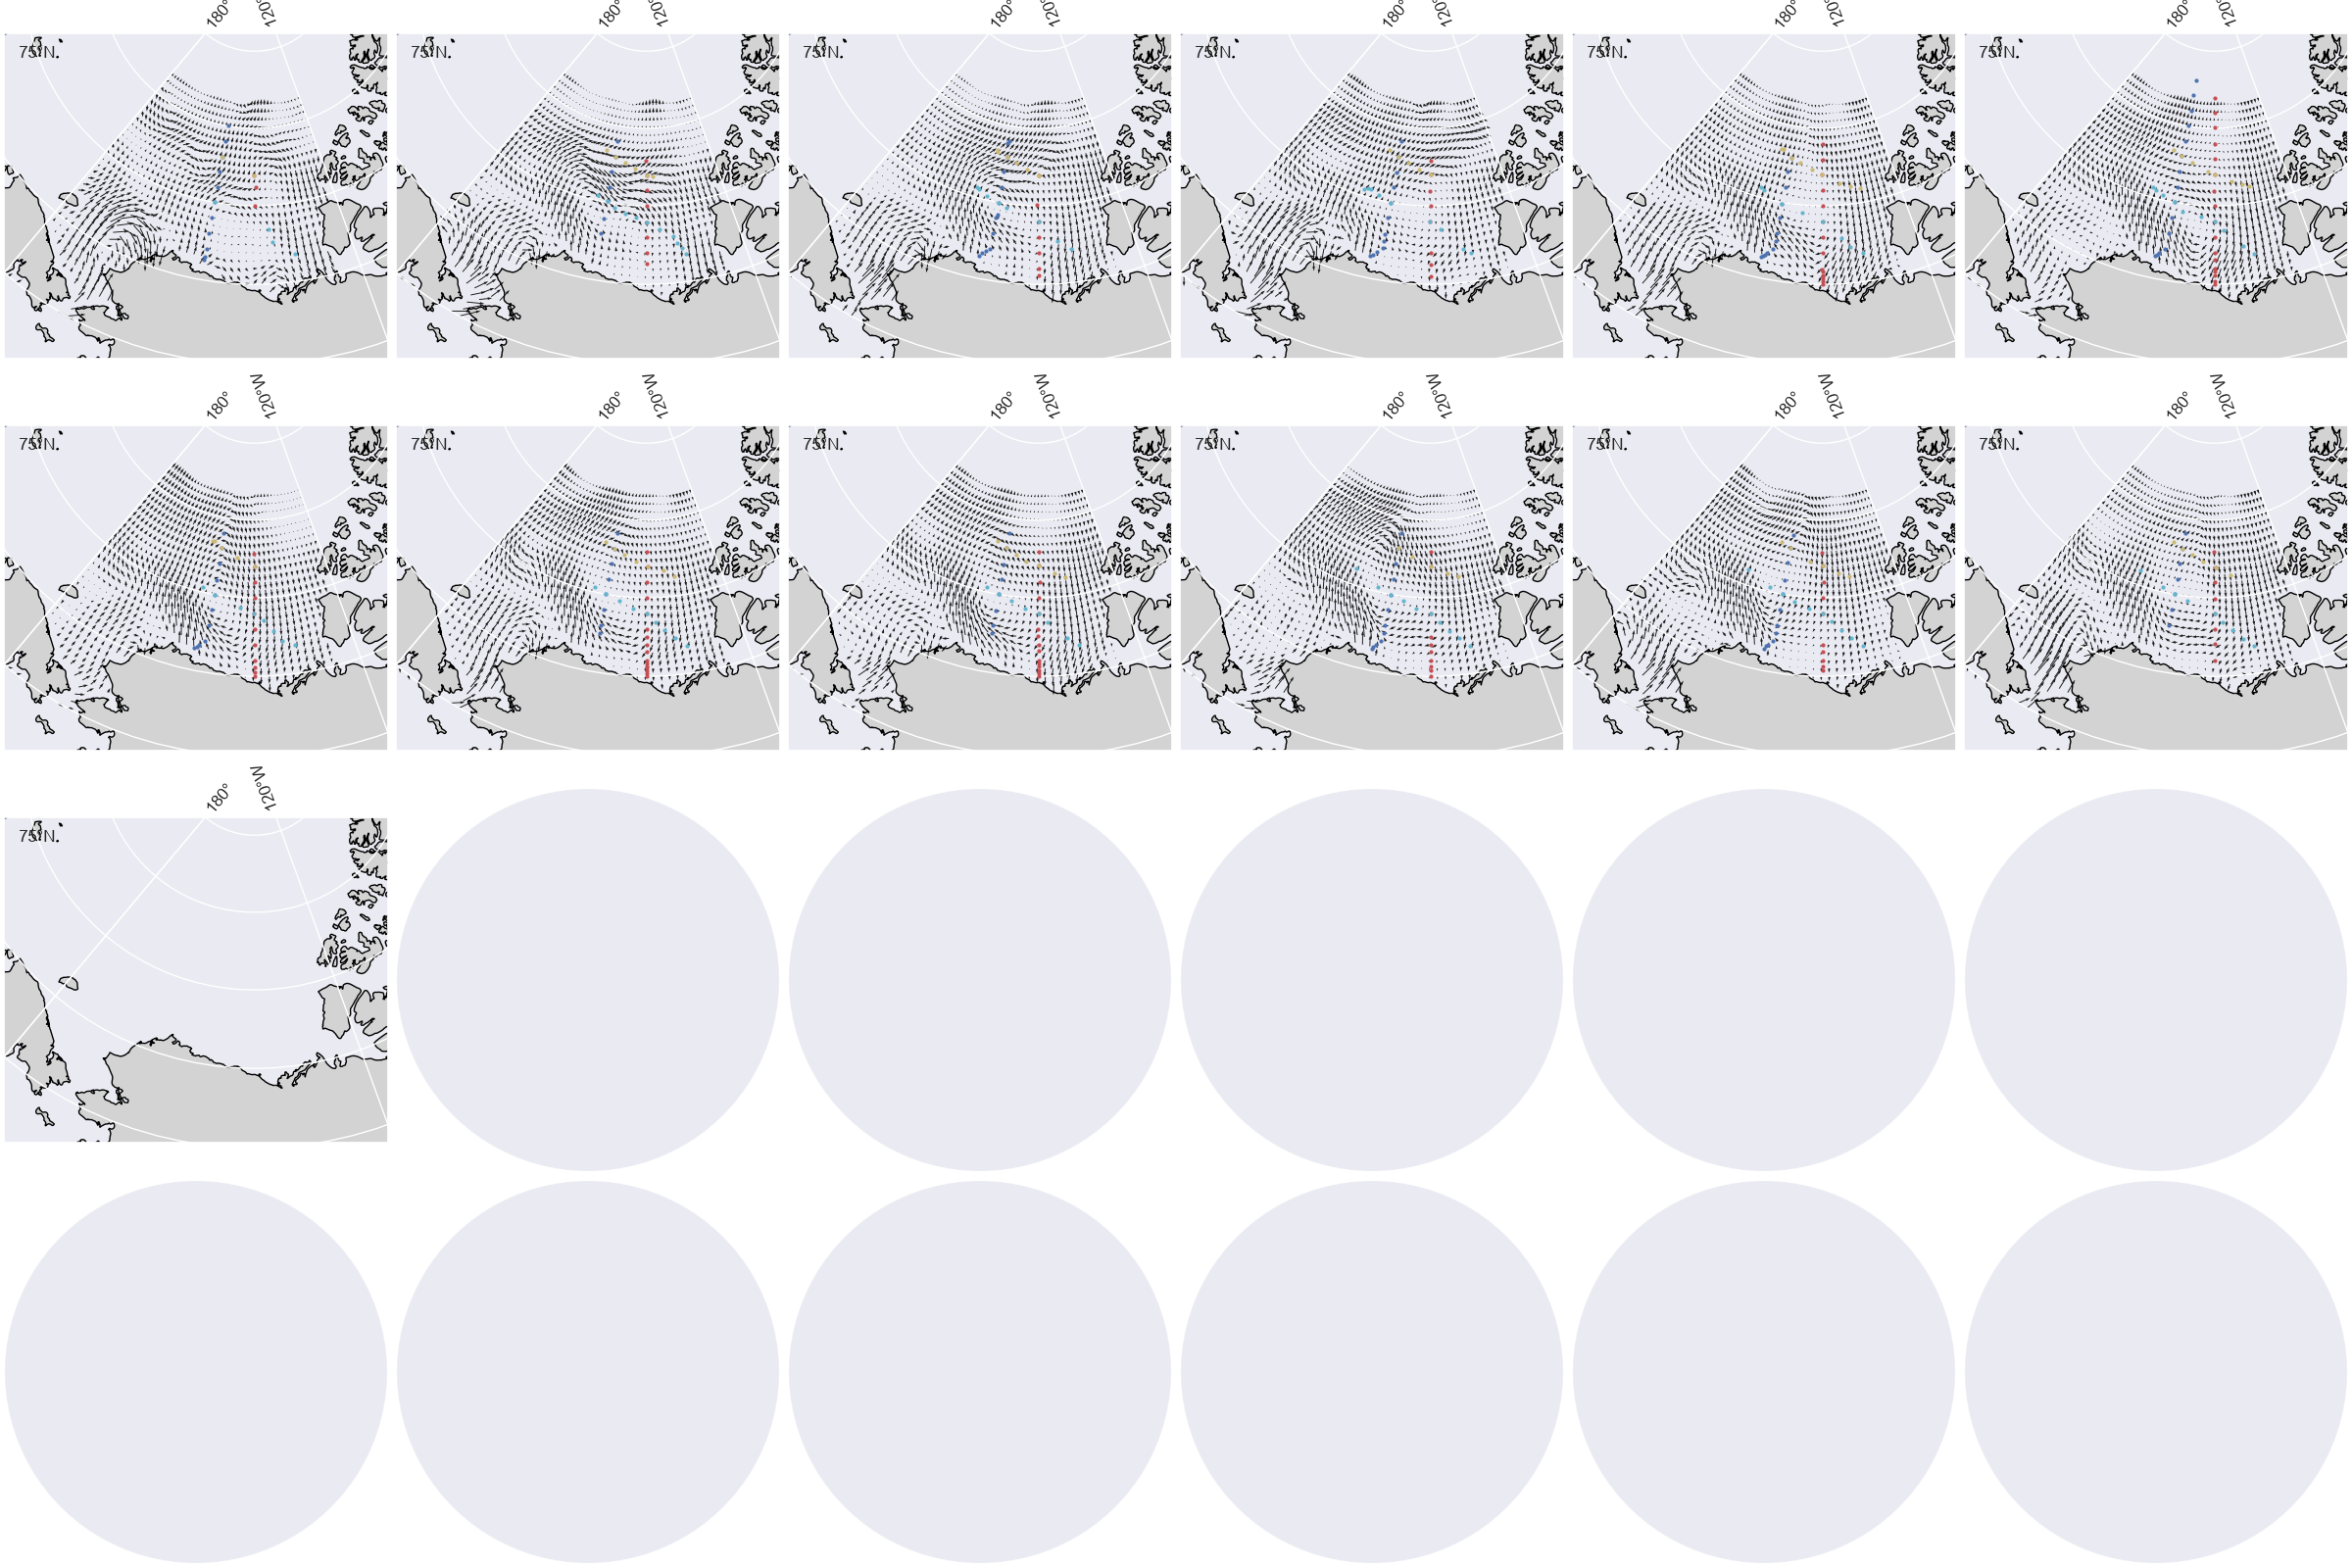

In [26]:
#Setup the basemap
transect_location_figure = plt.figure(figsize=(8,8))
projection=ccrs.NorthPolarStereo(central_longitude=-140)
extent = [-180, -120, 65, 85]
step = 2

mega_figure = plt.figure(figsize = (24, 16), layout="constrained")

sns.set_theme()

years = e_ns_cruise_transects.keys()
data_sets_dicts = [e_ns_cruise_transects, w_ns_cruise_transects, n_ew_cruise_transects, s_ew_cruise_transects]
track_names = ['140˚W South to North', '150˚W South to North', '78˚-75˚N West to East','76˚-71˚N West to East']
track_colors = ['r', 'b', 'y', 'c']

mega_figure.clf()
axs = mega_figure.subplots(4,6, subplot_kw={"projection": projection})

for i, year in enumerate(years):
    #Setbup basemap
    index = np.unravel_index(i, (4,6))
    ax = axs[index]
    ax.set_extent(extent, crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.LAND, facecolor="lightgray")
    ax.add_feature(cfeature.COASTLINE)
    ax.gridlines(draw_labels=True)

    #Draw currents
    plot_currents(year, ax)

    for j, transect_dict in enumerate(data_sets_dicts):
        transect = transect_dict[year]
        ax.plot(transect['lon'], 
                transect['lat'],
                marker = 'o', 
                markersize = 2, 
                color = track_colors[j],
                linestyle = 'None',
                transform = ccrs.PlateCarree(),
                label = track_names[j] if i == 0 else "_nolegend_")

    ax.set_title(f"September {year} Geostrophic Currents")

mega_figure.suptitle(f"Surface Geostrophic Currents")
plt.legend()
plt.savefig(f"/Users/ben/Desktop/3D-TEA-BAG/plots/18AUG26/surf_currents.png")





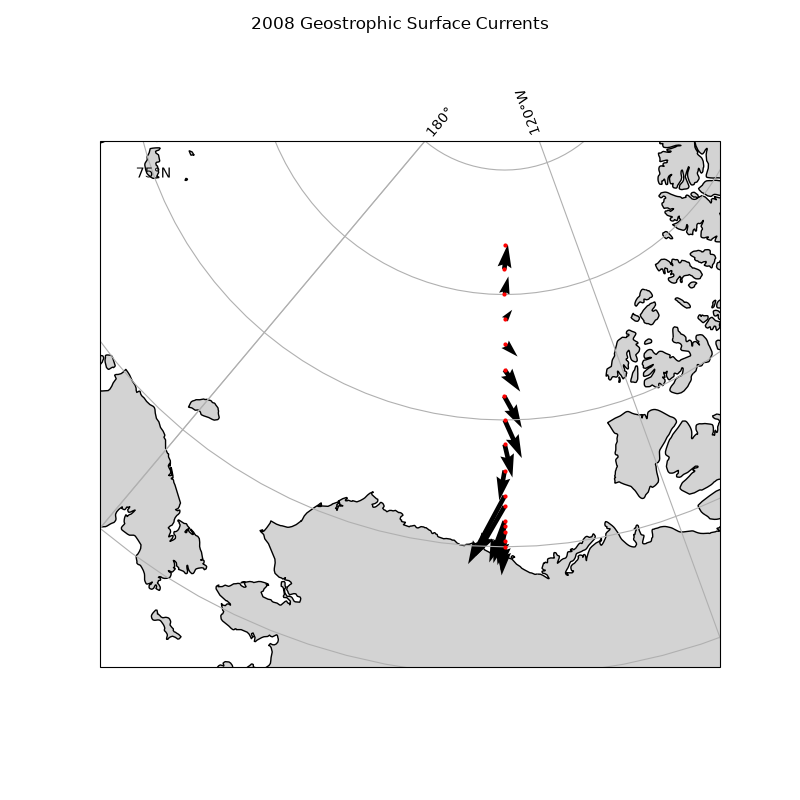

In [ ]:
transect = e_ns_cruise_transects[year]
transect_location_figure = plt.figure(figsize=(8,8))
projection=ccrs.NorthPolarStereo(central_longitude=-140)
extent = [-180, -120, 65, 85]

ax = mapper.setup_map(figure=transect_location_figure,
                 projection=projection,
                 extent=extent)

#Plot all stations
ax = mapper.plot_locations(ax, transect['lat'], transect['lon'], color = 'r', label = 'Stations')

#Get the surface currents
_, u_geo_surf_current, v_geo_surf_current = sat_data.get(transect['date'], transect['lat'], transect['lon'], priority='old')

#Plot the surface currents
ax.quiver(transect['lon'], transect['lat'], np.array(u_geo_surf_current), np.array(v_geo_surf_current), transform = ccrs.PlateCarree())


#Finish the plot off
transect_location_figure.suptitle(f"{year} Geostrophic Surface Currents") #WHY DOESNT THIS WORK?

plt.show()

In [20]:
axs.shape

(4, 6)